### **[A]: Choice of a population, with supporting expenditure data**

In [1]:
!pip install -r requirements.txt

In [17]:
#Importing
%pip install python-gnupg
%pip install eep153_tools
%matplotlib inline
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.simplefilter("ignore")

Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.


In [4]:
#Prices
ugd7_p0 = pd.read_csv('Data Files/Uganda - Food Prices (2018-19).csv')
ugd7_p0 = ugd7_p0[ugd7_p0["u"] == "Kg"]
ugd7_p = pd.pivot_table(ugd7_p0, values="price", index=["j","u"], columns=["t","m"] , aggfunc="median")
#Food Expenditures
ugd7_x0 = pd.read_csv('Data Files/Uganda - Food Expenditures (2018-19).csv')
ugd7_x0['i'] = ugd7_x0['i'].astype(str)
ugd7_x = pd.pivot_table(ugd7_x0, values="Expenditure", index=["i","t","m"], columns="j" , aggfunc="median")
#Consumption
ugd7_x_long = ugd7_x.stack().reset_index(name="Expenditure")
ugd7_p_long = ugd7_p0
ugd7_c = ugd7_x_long.merge(ugd7_p_long, on=["j", "t", "m"], how="left")
ugd7_c["Consumption"] = ugd7_c["Expenditure"] / ugd7_c["price"]
ugd7_c = ugd7_c.pivot_table(values="Consumption", index=["i","t","m","u"], columns="j", aggfunc="sum")
#HH Characteristics
ugd_z0 = pd.read_csv('Data Files/Uganda - Household Characteristics.csv')
ugd7_z = ugd_z0[ugd_z0['t'] == '2018-19']
ugd7_z = ugd7_z.set_index(['i','t','m'])
ugd7_z.columns.name = 'k'
ugd7_z.fillna(0, inplace=True)

### **[B]: Nutritional content of different foods**

In [5]:
#FCT
ugd_fct = pd.read_csv('Data Files/Uganda - FCT.csv')
ugd_fct = ugd_fct.rename(columns={"index":"j"}).set_index(["j"])
ugd_fct.columns.name = 'n'
#RDI
ugd_rdi = pd.read_csv('Data Files/Uganda - RDA.csv')
ugd_rdi = ugd_rdi.set_index(["n"])
ugd_rdi.columns.name = 'k'

### **[A]: Estimate demand system**

In [6]:
import cfe
from cfe import Regression

ugd7_result = cfe.Regression(y=np.log(ugd7_x.stack()),d=ugd7_z)

In [7]:
ugd7_result.predicted_expenditures()

i                                 t        m        j                     
004e93d7552248ed95d8bc3ec21bdbdb  2018-19  Eastern  Avocado                    913.847077
                                                    Beans (dry)               2097.050987
                                                    Beans (fresh)             2013.430063
                                                    Beef                      6065.187842
                                                    Biscuits                   593.880100
                                                                                 ...     
ffe756a5b2544583941f06fae0d2ecf8  2018-19  Eastern  Sweet Potatoes (fresh)    4670.733119
                                                    Tea (leaves)               154.653376
                                                    Tilapia (fresh)           5364.455162
                                                    Tomatoes                   917.454923
                         

<Axes: xlabel='yhat', ylabel='y'>

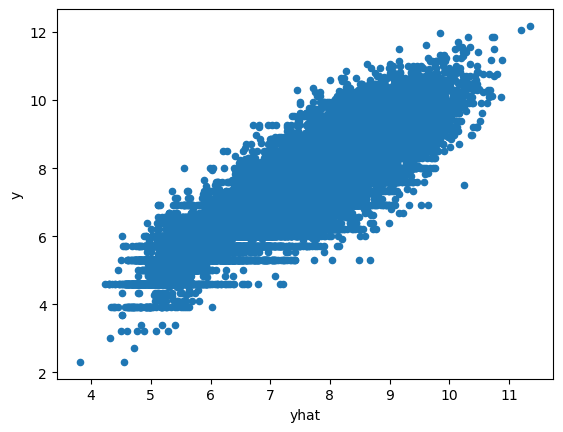

In [8]:
#Expenditures x may have duplicate columns
x1 = ugd7_x0.groupby(['i','t','m','j']).sum()
#Replace zeros with missing values
x1 = x1.replace(0,np.nan)
#Take logs of expenditures; call this y
y = np.log(x1["Expenditure"])
#Create dataframe with predicted yhat values
ugd3_acc = pd.DataFrame({'y':y,'yhat':ugd7_result.get_predicted_log_expenditures()})
#Plot yhat vs y (predicted vs actual)
ugd3_acc.plot.scatter(x='yhat',y='y')

In [9]:
ugd7_result.R2(summary=True)

np.float64(0.7469698627830735)

In [11]:
#Save result
ugd7_result.to_pickle('./Uganda18-19.rgsn')
##To access result:
#import cfe
#result = cfe.regression.read_pickle('Uganda18-19.rgsn')

### Parameters

**(Relative) Income Elasticity:** $\beta$ coefficients, which govern how *income elastic* different goods are (higher values means more elastic).  These are also called *Frisch elasticities*.
Here we use a plot to visualize, with confidence intervals.

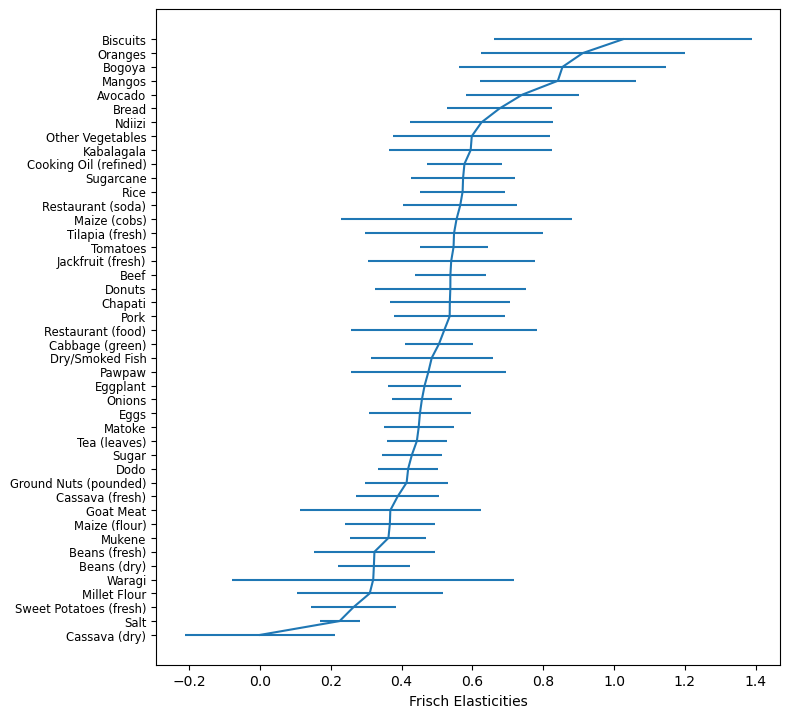

In [12]:
ax1 = ugd7_result.graph_beta()

In [13]:
ugd7_result.get_beta().sort_values(ascending=False)

j
Biscuits                  1.025338
Oranges                   0.911581
Bogoya                    0.854290
Mangos                    0.841248
Avocado                   0.740957
Bread                     0.676595
Ndiizi                    0.625661
Other Vegetables          0.598181
Kabalagala                0.595114
Cooking Oil (refined)     0.577508
Sugarcane                 0.573698
Rice                      0.572372
Restaurant (soda)         0.565508
Maize (cobs)              0.555111
Tilapia (fresh)           0.548109
Tomatoes                  0.546811
Jackfruit (fresh)         0.540137
Beef                      0.537891
Donuts                    0.537690
Chapati                   0.536262
Pork                      0.535827
Restaurant (food)         0.520493
Cabbage (green)           0.505524
Dry/Smoked Fish           0.485189
Pawpaw                    0.475851
Eggplant                  0.465054
Onions                    0.457411
Eggs                      0.451886
Matoke            

**Demand and Household Composition:** $\gamma_j$ parameters in the regression, which capture the effects of household composition on demand

In [14]:
ugd7_result.get_gamma()

k,F 00-03,M 00-03,F 04-08,M 04-08,F 09-13,M 09-13,F 14-18,M 14-18,F 19-30,M 19-30,F 31-50,M 31-50,F 51+,M 51+,log HSize,Constant
j,,,,,,,,,,,,,,,,
Avocado,0.028836,0.071353,0.083283,0.050952,0.003248,0.060258,0.070893,-0.123135,0.059093,0.058879,0.141633,0.033159,0.046860,0.068392,0.098942,7.364156
Beans (dry),-0.030351,-0.035695,-0.005948,0.021989,0.016419,0.035592,0.119661,-0.026421,-0.017905,0.032402,0.063794,0.007742,0.033507,0.086370,0.437220,8.112556
Beans (fresh),-0.117205,0.031699,-0.055022,0.119153,-0.112255,-0.093502,0.029730,-0.154297,0.071390,0.057337,0.054709,-0.061394,-0.219200,0.052514,0.532313,8.314207
Beef,-0.013593,0.011631,-0.004935,0.029071,0.069925,0.154259,0.148422,-0.075991,-0.008732,-0.024918,-0.002887,0.046599,0.144188,0.114156,0.256068,9.222827
Biscuits,-0.166034,-0.220521,-0.067040,-0.260210,0.066074,0.006785,0.311196,-0.225092,-0.120021,-0.108824,-0.334457,-0.129101,-0.000246,-0.005319,0.860569,6.688872
Bogoya,-0.167493,0.043269,-0.144032,0.014780,-0.007978,0.121180,-0.007131,0.019233,-0.015568,-0.005736,-0.156196,0.045786,-0.027232,0.214925,0.450868,7.685120
Bread,-0.082349,0.033810,0.006353,0.033251,0.137467,0.177872,0.214839,-0.164861,0.096254,-0.028184,-0.032038,0.115843,0.250104,0.154783,0.108282,8.126034
Cabbage (green),0.028838,0.047991,0.033812,0.110797,0.035061,0.015627,0.096752,-0.003049,0.021817,0.003112,0.031486,0.069219,0.070310,0.097708,0.076650,7.012228
Cassava (dry),0.017922,0.100290,-0.007452,0.068627,0.013655,0.225039,0.217567,-0.043841,0.074853,0.048914,0.099293,0.056605,0.069788,-0.064718,0.234595,8.609605


**Welfare:** $w_i$ parameters, which are a welfare measure for the household.

<Axes: ylabel='Density'>

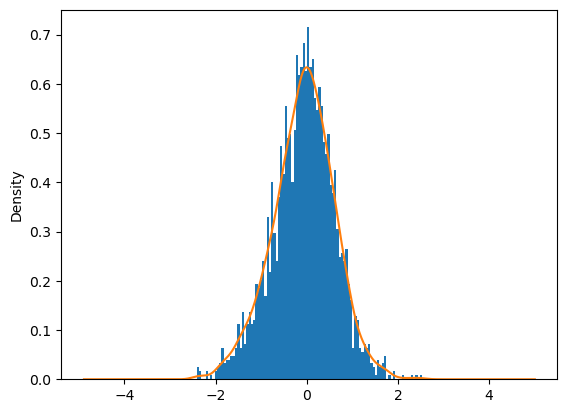

In [15]:
ax2 = ugd7_result.get_w().plot.hist(bins=100,density=True)
ugd7_result.get_w().plot.kde(ax=ax2)

### Demand and Utility

**Budgets:** Get food budget for all households, then find median budget

In [16]:
xhat = ugd7_result.predicted_expenditures()
#Total food expenditures per household
xbar = xhat.groupby(['i','t','m']).sum()
#Reference budget
xref = xbar.quantile(0.5)  # Household at 0.5 quantile is median

**Reference Prices:** Choose reference prices.  Here we chose the year 2015 and averaged prices across markets.

In [18]:
#Prices per kilogram:
pbar = ugd7_p.mean(axis=1)
pbar = pbar.reset_index(level="u", drop=True) #Reset index so that 'j' becomes a column instead of part of a MultiIndex
pbar = pbar.reindex(ugd7_result.beta.index) #Only use prices for goods we can estimate
#Replace missing prices with 1 (this is because they're best measured in expenditures)
pbar = pbar.replace(np.nan,1)
#Define a function to change a single price in the vector $p$:
def my_prices(p0,j,p=pbar):
    """
    Change price of jth good to p0, holding other prices fixed.
    """
    p = p.copy()
    p.loc[j] = p0
    return p

**Demand as a function of prices:** Demand schedules for households with different budgets

Text(0.5, 0, 'Quantities of Beef Demanded')

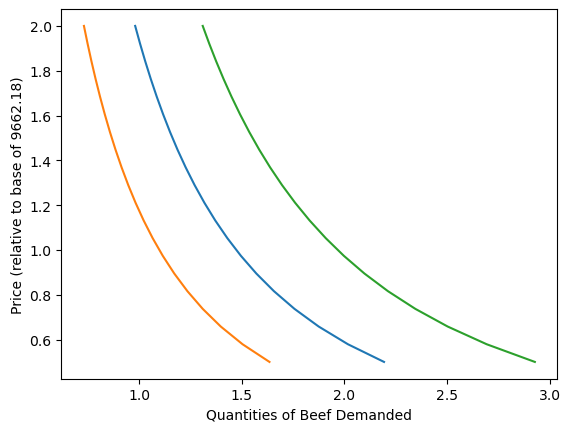

In [19]:
use = 'Beef'  #Good we want demand curve for

#Vary prices from 50% to 200% of reference.
scale = np.linspace(.5,2,20)

#Demand for Millet for household at median budget
plt.plot([ugd7_result.demands(xref,my_prices(pbar[use]*s,use,pbar))[use] for s in scale],scale)

#Demand for Millet for household at 25% percentile
plt.plot([ugd7_result.demands(xbar.quantile(0.25),my_prices(pbar[use]*s,use,pbar))[use] for s in scale],scale)

#Demand for Millet for household at 75% percentile
plt.plot([ugd7_result.demands(xbar.quantile(0.75),my_prices(pbar[use]*s,use,pbar))[use] for s in scale],scale)

plt.ylabel(f"Price (relative to base of {pbar[use]:.2f})")
plt.xlabel(f"Quantities of {use} Demanded")

**Engel Curves:** Tracing how demand changes with budget

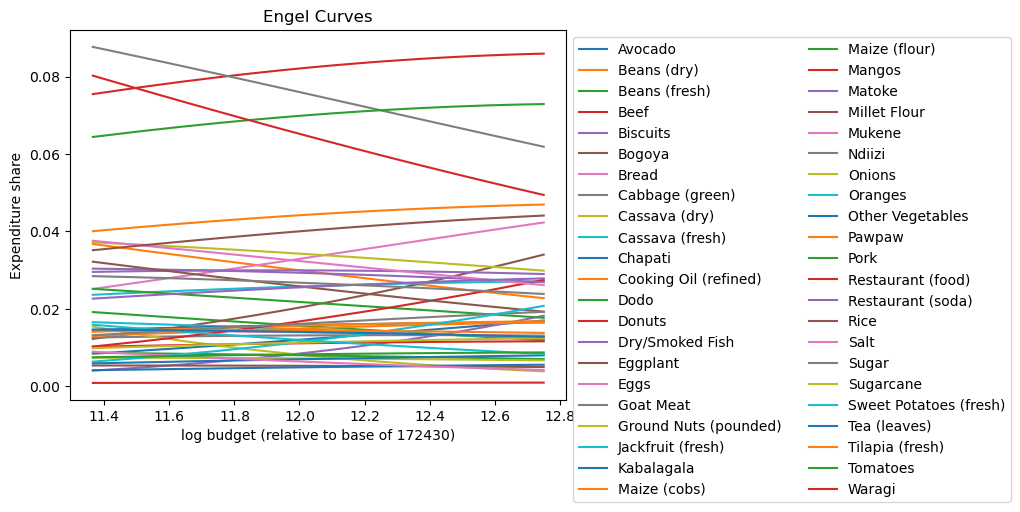

In [20]:
fig,ax = plt.subplots()

ax.plot(np.log(scale*xref),[ugd7_result.expenditures(s*xref,pbar)/(s*xref) for s in scale])
ax.set_xlabel(f'log budget (relative to base of {xref:.0f})')
ax.set_ylabel(f'Expenditure share')
ax.set_title('Engel Curves')
ax.legend(ugd7_result.expenditures(xref,pbar).index.tolist(), loc="upper left", bbox_to_anchor=(1, 1), ncol=2)

**Indirect Utility Function:**

Text(0.5, 1.0, 'Indirect Utility Function')

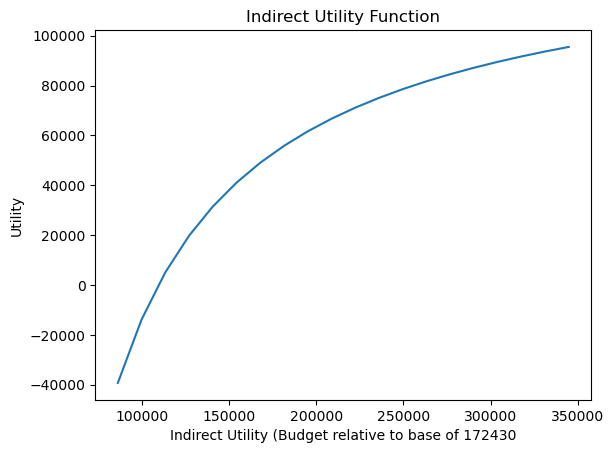

In [21]:
fig,ax = plt.subplots()

ax.plot(scale*xref,[ugd7_result.indirect_utility(s*xref,pbar) for s in scale])
ax.set_xlabel(f'Indirect Utility (Budget relative to base of {xref:.0f}')
ax.set_ylabel(f'Utility')
ax.set_title('Indirect Utility Function')

### **[B]: Nutritional adequacy of diet**

In [22]:
#Get result saved above
ugd7_result = cfe.read_pickle('Uganda18-19.rgsn')
#Quantities in kg: expenditures divided by prices/kg
qhat = (xhat.unstack('j')/ugd7_p.reset_index(drop=True, level="u").transpose()).dropna(how='all')
#Drop missing columns
qhat = qhat.loc[:,qhat.count()>0]

In [23]:
#Columns of qhat to match fct
use = ugd_fct.index.intersection(qhat.columns)

nutrients = qhat[use]@ugd_fct.loc[use,:]
nutrients.mean()    # NB: Nutrients are for past /week/ for entire household

n
Energy          199711.472097
Protein           6472.379052
Fiber             2699.805813
Folate           43559.612082
Calcium          25306.964417
Carbohydrate     26824.947855
Iron              1040.499152
Niacin            1518.348095
Riboflavin          92.048123
Thiamin            134.312831
Vitamin A        25647.238165
Vitamin B-12       282.708210
Vitamin B-6        233.014769
Vitamin C        12648.512877
Zinc               589.923855
Magnesium          258.467155
Phosphorus        3941.440676
Potassium         2045.874372
Vitamin E           83.501040
Vitamin K         1347.630527
dtype: float64

In [24]:
#Obtain recommended daily intake
ugd7_z = ugd7_z[ugd_rdi.columns.tolist()]
hh_rdi = ugd7_z@ugd_rdi.T
#Make this a recommended WEEKLY intake
hh_rwi = hh_rdi*7
# Match up nutrient names
use_nutrients = nutrients.columns.intersection(hh_rwi.columns)
nutrient_ratio = (nutrients[use_nutrients]/hh_rwi[use_nutrients]).dropna()
#Display
nutrient_ratio

,,n,Energy,Protein,Fiber,Folate,Calcium,Carbohydrate,Iron,Niacin,Riboflavin,Thiamin,Vitamin A,Vitamin B-12,Vitamin B-6,Vitamin C,Zinc,Magnesium,Phosphorus,Potassium,Vitamin E,Vitamin K
i,t,m,,,,,,,,,,,,,,,,,,,,
004e93d7552248ed95d8bc3ec21bdbdb,2018-19,Eastern,3.413957,4.744746,2.860902,3.062679,0.515612,4.616654,2.672176,3.173102,2.423766,3.663494,1.172212,3.744460,5.650261,7.496669,2.041899,0.031394,0.126714,0.011957,0.241889,0.691647
0071da69d26d4b29a8f9d29d458e68cf,2018-19,Northern,5.894238,9.854141,5.478524,6.735729,1.100813,7.209386,4.846281,6.439613,5.015112,6.847938,2.551635,8.258325,10.450213,18.923195,4.042317,0.066111,0.242279,0.022990,0.372180,1.082287
008071c371724fe49a5bb047472df87f,2018-19,Eastern,2.875758,3.781466,2.422311,2.970874,0.571020,5.269029,2.905634,2.780710,2.045027,3.328773,0.966004,3.384611,5.631787,5.901333,1.647546,0.024366,0.116800,0.013118,0.222978,0.625140
00854d05d4f044c985ffce60c1b514c2,2018-19,Western,3.352302,4.475487,3.595991,4.324669,0.695005,6.908504,3.374782,3.545980,2.880871,4.494296,0.874661,3.480007,6.548461,4.382446,2.160853,0.032347,0.195255,0.019682,0.167211,0.306568
00858c2384184dc3bfc800550a6c8cb5,2018-19,Northern,2.846966,4.198594,2.921350,3.966487,0.770542,5.726163,2.594386,3.102754,2.379651,3.813067,1.175763,3.814379,5.866172,6.862276,1.938672,0.022960,0.137405,0.012234,0.157009,0.369661
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
ff6cde2ccba544629beef9be7f4999c1,2018-19,Central,2.411222,3.824118,2.121894,2.537889,0.479856,4.024264,2.326669,2.747995,1.996246,2.719817,0.664612,3.752166,4.086885,3.074117,1.636545,0.017503,0.105318,0.009382,0.155283,0.401933
ff75528be9d54f6d810710b90fa41ea7,2018-19,Northern,2.604927,4.064525,2.599370,3.258552,0.640669,4.542247,2.495932,2.970176,2.273644,3.264497,1.137788,3.952745,5.136970,6.807728,1.739315,0.016616,0.088454,0.008238,0.150684,0.382895
ff86ad516c3b4415a245988155f93052,2018-19,Eastern,2.552548,3.532814,2.812590,3.310447,0.574406,5.431136,2.474478,2.673480,2.067318,3.499973,0.933327,2.549469,5.550264,5.232274,1.780044,0.014069,0.088466,0.007327,0.115658,0.272803


<Axes: >

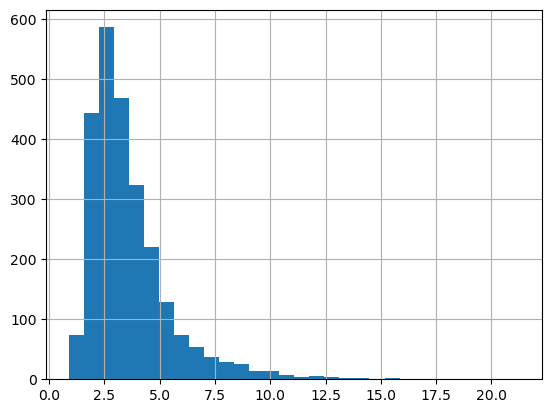

In [25]:
#Plot nutrient ratio for specific nutrient
%matplotlib inline
nutrient_ratio['Energy'].hist(bins=30)